# Modelo FINANOM — pipeline híbrido consolidado (Adrian + Tony + Rogelio)

Apoyo al auditor nocturno. Este notebook documenta el modelo que **consolida lo mejor del trabajo de los tres**:

| Componente | Origen | Qué aporta |
|---|---|---|
| Pipeline de datos + features (`feat_*`) | **Adrian** | base limpia, 63 features, trazabilidad |
| Isolation Forest: muestreo **estratificado** + umbral **adaptativo** | **Rogelio** | IF más estable y umbral data-driven |
| Motor de **reglas de negocio** (8 detectores tipados) | **Tony** | inconsistencias explicables con catálogos de códigos |
| Regla **método de pago** (Visa↔Amex) | **Adrian** | tipo que Tony no cubría |
| Explicabilidad **SHAP** (TreeExplainer) | **Rogelio** | evidencia por transacción del IF |

Pipeline reproducible: [`train_model.py`](train_model.py) · `uv run python model_Adrian/train_model.py`

## 1. Arquitectura híbrida

- **Isolation Forest** (no supervisado) sobre las 63 `feat_*` → `anomaly_score` continuo. Entrenado con muestreo estratificado (Rogelio) en el 80% temporal más antiguo; umbral por mayor salto en la cola.
- **Reglas tipadas** (Tony, importadas de `Tony_anomaly_detection.reglas`) + método de pago (Adrian) sobre la base limpia → tipo + motivo legible + `rule_score`.
- **SHAP** (Rogelio) sobre las filas que marca el IF → evidencia de qué features la aislaron.
- **Cola de revisión** = `rule_score≥60` ∪ IF ∪ método_pago (severidad ALTO/CRÍTICO), rankeada por severidad y score.

In [1]:
from pathlib import Path
import sys, json
import numpy as np, pandas as pd

p = Path.cwd()
ROOT = next((x for x in [p, *p.parents] if (x / 'pyproject.toml').exists()), p)
sys.path.insert(0, str(ROOT))
from model_Adrian import train_model as tm   # fija backend Agg
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt

paths = tm.TrainingPaths.from_dir()
if not paths.report_parquet.exists():
    tm.run_training()  # genera artefactos si no existen

report = pd.read_parquet(paths.report_parquet)
diag = json.loads(paths.eval_json_file.read_text(encoding='utf-8'))
print('Reporte:', report.shape, '| en cola:', int(report['is_anomaly'].sum()))

/Users/adrianmateos/Documents/RetoOctavo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reporte: (1145526, 20) | en cola: 47087


## 2. La cola de revisión

En este hotel las cancelaciones (~11%) y los duplicados (~8%) son **comunes**, así que el umbral operativo base de las reglas marcaría ~20%. Subimos el corte para dejar una cola revisable por el auditor (~4%), priorizada por severidad.

In [2]:
print('Severidad (toda la base):')
print(report['severidad'].value_counts().reindex(['CRITICO','ALTO','MEDIO','BAJO']).to_string())
m = report[report['is_anomaly']]
print(f'\nCola de revisión: {len(m):,} ({100*len(m)/len(report):.2f}% de la base)')

from collections import Counter
c = Counter()
for cl in m['tipo_inconsistencia']:
    for part in str(cl).split(' | '):
        if part: c[part] += 1
pd.Series(dict(c.most_common())).rename('en_cola').to_frame()

Severidad (toda la base):
severidad
CRITICO     18917
ALTO        28170
MEDIO      216395
BAJO       882044

Cola de revisión: 47,087 (4.11% de la base)


,en_cola
CANCELACION_SOSPECHOSA,36249
DUPLICADO,34358
CONTEXTO_RESERVACION,9398
FUERA_DE_ESTANCIA,6682
MONTO_ATIPICO,5546
ATIPICO_IF,1404
METODO_PAGO,28
PAGO_PROVEEDOR_SOSPECHOSO,15
SIGNO_CONTABLE,8


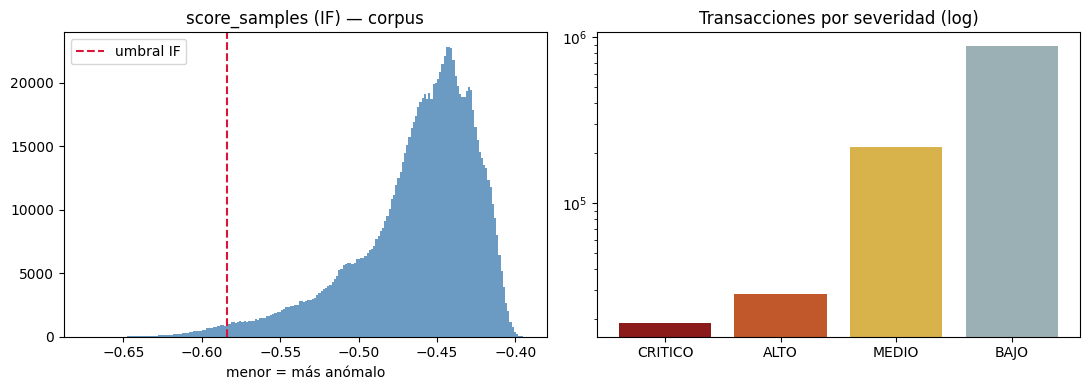

In [3]:
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.hist(report['score_samples'], bins=200, color='steelblue', alpha=0.8)
plt.axvline(diag['threshold_score_samples'], color='crimson', ls='--', label='umbral IF')
plt.title('score_samples (IF) — corpus'); plt.legend(); plt.xlabel('menor = más anómalo')
plt.subplot(1,2,2)
sev_order=['CRITICO','ALTO','MEDIO','BAJO']
vc=report['severidad'].value_counts().reindex(sev_order)
plt.bar(sev_order, vc.values, color=['#8b1a1a','#c1582b','#d8b24a','#9bb0b5'])
plt.yscale('log'); plt.title('Transacciones por severidad (log)')
plt.tight_layout(); plt.show()

## 3. Anomalías priorizadas con su explicación

Cada alerta trae tipo, motivo legible (mensaje de las reglas de Tony o evidencia SHAP), severidad y `rule_score`. Lista para que el auditor revise y apruebe (human-in-the-loop).

In [4]:
cols = ['trace_t_folio','trace_t_codigo','severidad','rule_score','anomaly_score','tipo_inconsistencia','motivos']
m.sort_values(['severidad','anomaly_score'], ascending=[True,False]).head(10)[cols]

,trace_t_folio,trace_t_codigo,severidad,rule_score,anomaly_score,tipo_inconsistencia,motivos
768012,77178,RENAJU,ALTO,45,0.662954,MONTO_ATIPICO | CONTEXTO_RESERVACION,"Alerta tx 64 (folio 77178, cód RENAJU, monto 1..."
1047767,107525,RENAJU,ALTO,45,0.657771,MONTO_ATIPICO | CONTEXTO_RESERVACION,"Alerta tx 101 (folio 107525, cód RENAJU, monto..."
633032,59524,XFAC,ALTO,45,0.657227,CANCELACION_SOSPECHOSA | CONTEXTO_RESERVACION,"Alerta tx 159 (folio 59524, cód XFAC, monto 56..."
1096993,131626,RENAJU,ALTO,0,0.656752,ATIPICO_IF,Patron atipico detectado por Isolation Forest ...
954193,91676,RENAJU,ALTO,45,0.655759,MONTO_ATIPICO | CONTEXTO_RESERVACION,"Alerta tx 111 (folio 91676, cód RENAJU, monto ..."
478071,121736,RENAJU,ALTO,20,0.653955,CONTEXTO_RESERVACION,"Alerta tx 105 (folio 121736, cód RENAJU, monto..."
591501,71907,RENAJU,ALTO,25,0.653611,MONTO_ATIPICO,"Alerta tx 82 (folio 71907, cód RENAJU, monto 2..."
1066368,111827,RENAJU,ALTO,45,0.652834,MONTO_ATIPICO | CONTEXTO_RESERVACION,"Alerta tx 58 (folio 111827, cód RENAJU, monto ..."
609609,125327,RENAJU,ALTO,25,0.652330,MONTO_ATIPICO,"Alerta tx 78 (folio 125327, cód RENAJU, monto ..."
866887,58881,XFAC,ALTO,45,0.652205,MONTO_ATIPICO | CONTEXTO_RESERVACION,"Alerta tx 26 (folio 58881, cód XFAC, monto 308..."


## 4. Evaluación recursiva (sin etiquetas)

### 4.1 Inyección sintética — el IF solo NO basta
Anomalías extremas en 1-2 dimensiones inyectadas en filas normales. El IF global las **diluye** (*swamping* entre 63 features) y no las prioriza → recall bajo. Las reglas tipadas las capturan por construcción. **Por eso el modelo es híbrido.**

In [5]:
inj = diag['injection_recall']
pd.Series({k: f'{v:.1%}' for k,v in inj.items()}, name='recall IF').to_frame()

,recall IF
monto_inflado,0.0%
duplicado_extremo,0.0%
cargo_fuera_estancia,0.0%
modificacion,0.0%
promedio,0.0%


### 4.2 Overlap IF ↔ reglas — la evidencia del valor híbrido
Las dos capas son **casi disjuntas**: cada una aporta alertas que la otra no ve. El IF da los atípicos multidimensionales desconocidos; las reglas, los tipos de negocio concretos y explicables.

Overlap IF vs reglas operativas:
  if_flagged: 14,692
  reglas_operativas: 232,558
  interseccion: 11,004
  solo_reglas: 221,554
  solo_if: 3,688


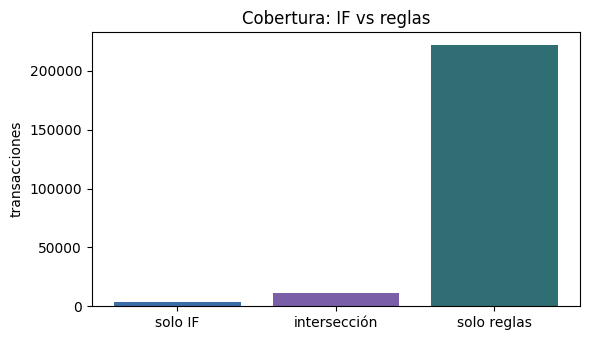

In [6]:
ov = diag['overlap']
print('Overlap IF vs reglas operativas:')
for k,v in ov.items(): print(f'  {k}: {v:,}')
plt.figure(figsize=(6,3.5))
plt.bar(['solo IF','intersección','solo reglas'],
        [ov['solo_if'], ov['interseccion'], ov['solo_reglas']],
        color=['#3b6ea8','#7b5ea8','#2f6f73'])
plt.ylabel('transacciones'); plt.title('Cobertura: IF vs reglas'); plt.tight_layout(); plt.show()

### 4.3 Estabilidad temporal y evidencia SHAP
La tasa de marcado del IF es estable entre el periodo de entrenamiento y el reciente. El SHAP (abajo) muestra qué features pesan más en las filas que marca el IF.

Estabilidad (tasa de marcado IF por periodo):
  entrenamiento: 1.30%
  reciente: 1.19%


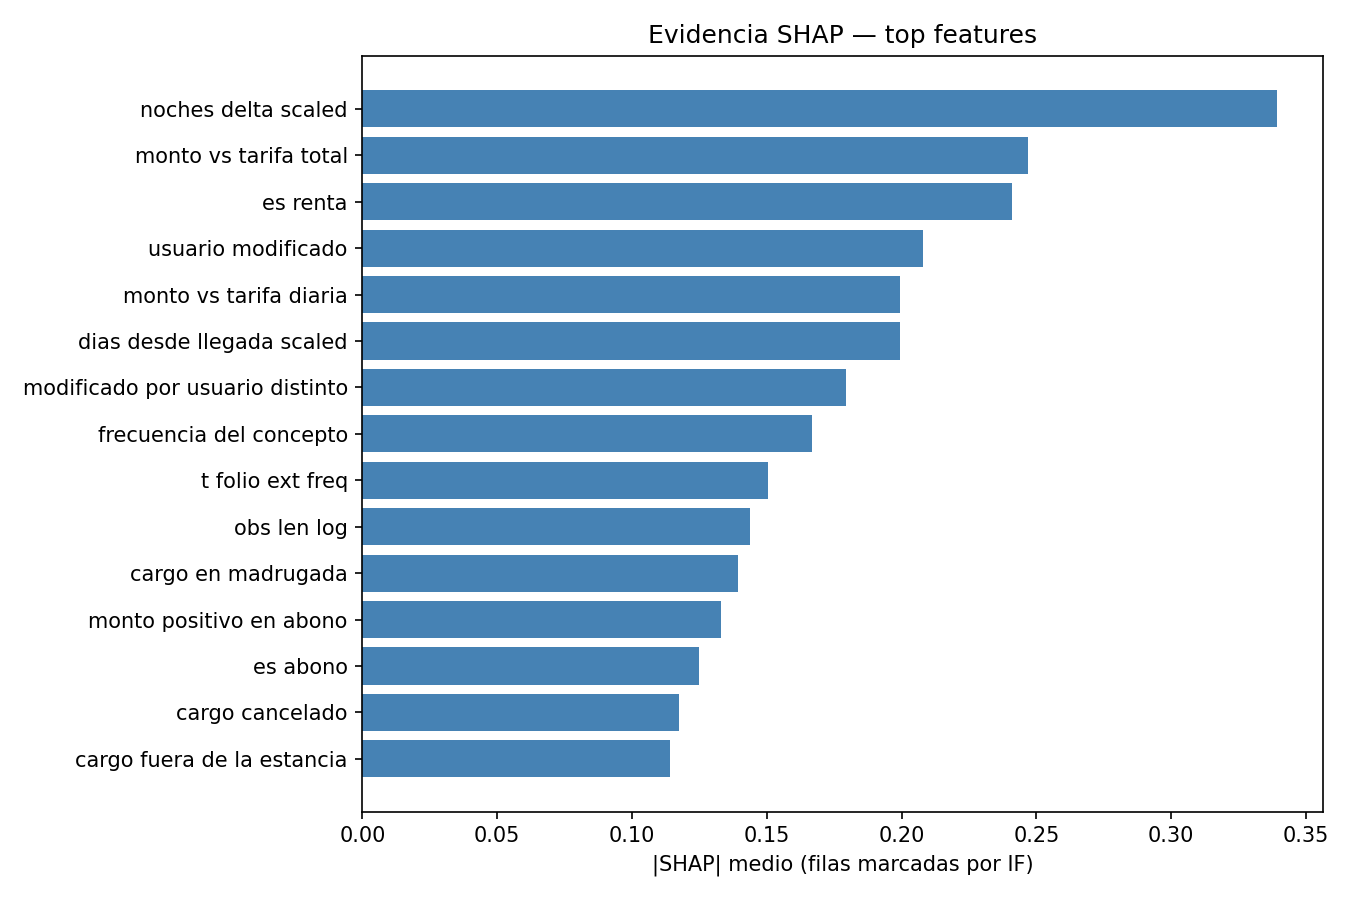

In [7]:
print('Estabilidad (tasa de marcado IF por periodo):')
for per,s in diag['stability'].items():
    print(f'  {per}: {s["tasa_marcado"]:.2%}')
from IPython.display import Image, display
if paths.shap_plot_file.exists(): display(Image(filename=str(paths.shap_plot_file)))

## 5. Bucle de feedback del auditor — el modelo que aprende

Módulo [`feedback.py`](feedback.py). Mecanismo: **adaptación de umbral/pesos**. El auditor marca cada alerta como `anomalia_confirmada` o `falso_positivo` (se anexa a `output/feedback_labels.csv`, compatible con el etiquetado del dashboard de Tony). Con eso:

- `feedback_metrics()` mide la precisión de las alertas (global / por severidad / por tipo).
- `suggest_threshold()` endurece el umbral si hay demasiados falsos positivos, o lo afloja si la precisión es alta (control proporcional).
- `save_feedback_state()` persiste lo aprendido para el siguiente scoring.

Queda como TODO documentado el ajuste de pesos por regla (`suggest_rule_weight_deltas`) y el enganche en el scoring (`apply_learned_state`). Abajo, el ciclo con feedback **simulado** sobre la cola actual.

In [8]:
from model_Adrian import feedback

# Estado real del almacen (vacío hasta que el auditor revise)
labels = feedback.load_feedback(paths.labels_store_file)
print('etiquetas reales registradas:', len(labels))

# Demostración del ciclo con feedback SIMULADO sobre la cola actual
cola = report[report['is_anomaly']].head(60)
_rng = np.random.default_rng(0)
sim = cola[['trace_row_id']].assign(
    decision=_rng.choice(['anomalia_confirmada', 'falso_positivo'], len(cola), p=[0.45, 0.55]))
metrics = feedback.feedback_metrics(report, sim)
print('precisión global simulada:', metrics['precision_global'])
feedback.suggest_threshold(diag['threshold_score_samples'], metrics)

etiquetas reales registradas: 0
precisión global simulada: 0.433


{'cambiar': False,
 'umbral_nuevo': -0.5838147071972737,
 'motivo': 'precision 0.43 dentro de la banda objetivo'}

## 6. Limitaciones

- **No supervisado**: calidad validada por inyección/overlap, no por etiquetas reales.
- **Método de pago**: Amex (`AMEXCO`) separable; Visa vs Mastercard no (ambos `TARCRE`).
- **Sin datos de factura** (vacíos en MX): se aproxima vía monto/duplicado/reposteo.
- **Cancelaciones/duplicados comunes** en este hotel: se priorizan los casos de mayor `rule_score` (multi-regla) para no inundar la cola.
- **Siguiente**: implementar el ajuste de pesos por regla y el enganche del estado aprendido en el scoring (`feedback.py`).